<a href="https://colab.research.google.com/github/MariiaYarmolenko/HEALTHCARE-ANALYTICS-ECOSYSTEM/blob/main/HW_16_1_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BE%D1%80%D0%B5%D0%BD%D0%B4%D0%BD%D0%BE%D1%97_%D0%BF%D0%BB%D0%B0%D1%82%D0%B8_%D0%B7%D0%B0_%D0%B6%D0%B8%D1%82%D0%BB%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Навчання DA/House_Rent_Dataset.csv')

In [10]:
df.shape

(4746, 12)

In [5]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [12]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


In [11]:
stats = df.describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [15]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (оренда)',
    labels={'Rent': 'Вартість оренди', 'count': 'Кількість пропозицій'}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

In [16]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

print(f"Початкова кількість записів: {len(df)}")
print(f"Кількість після видалення викидів: {len(df_cleaned)}")

Початкова кількість записів: 4746
Кількість після видалення викидів: 4226


In [17]:
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

unique_counts = {col: df_cleaned[col].nunique() for col in categorical_cols}

print("Кількість унікальних значень у категоріальних змінних:")
for col, count in unique_counts.items():
    print(f"{col}: {count}")

Кількість унікальних значень у категоріальних змінних:
Posted On: 80
Floor: 340
Area Type: 3
Area Locality: 1997
City: 6
Furnishing Status: 3
Tenant Preferred: 3
Point of Contact: 3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


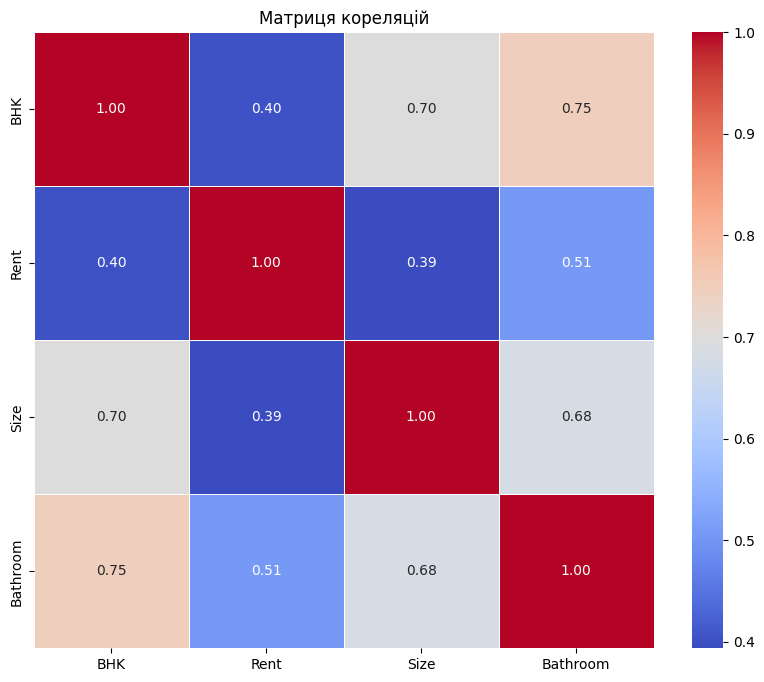

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матриця кореляцій')
plt.show()

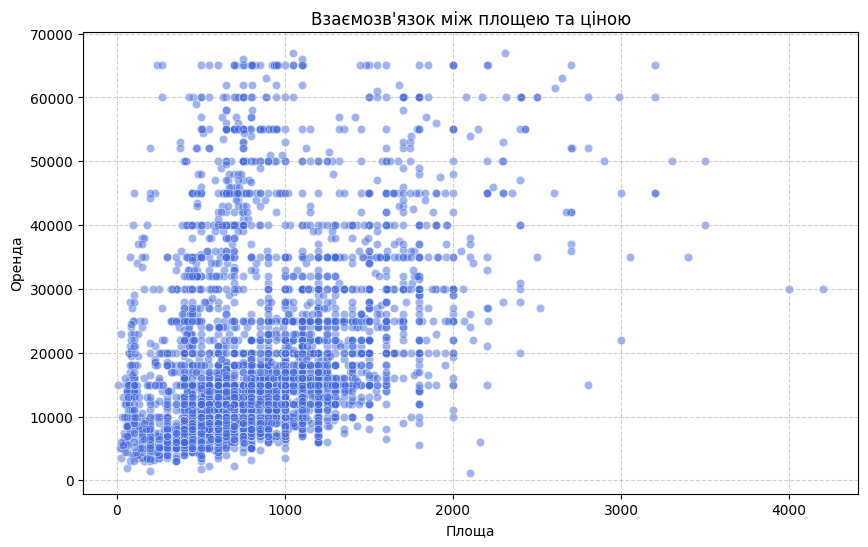

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Size', y='Rent', alpha=0.5, color='royalblue')
plt.title('Взаємозв\'язок між площею та ціною')
plt.xlabel('Площа')
plt.ylabel('Оренда')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_ml = df_cleaned.copy()

df_ml['Bath_per_BHK'] = df_ml['Bathroom'] / df_ml['BHK']

cols_to_drop = ['Posted On', 'Area Locality', 'Floor', 'Point of Contact']
df_filtered = df_ml.drop(columns=cols_to_drop)

In [35]:
df_final = pd.get_dummies(df_filtered, drop_first=True)

X = df_final.drop('Rent', axis=1)
y = df_final['Rent']

In [36]:
num_cols = ['BHK', 'Size', 'Bathroom', 'Bath_per_BHK']
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    'Ознака': X.columns,
    'Вага': model.coef_
})

coefficients['Abs_Weight'] = coefficients['Вага'].abs()
top_features = coefficients.sort_values(by='Abs_Weight', ascending=False)

print("Усі коефіцієнти моделі:")
print(coefficients[['Ознака', 'Вага']].to_string(index=False))

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Розмір навчальної вибірки: {len(y_train_pred)}")
print(f"Розмір тестової вибірки: {len(y_test_pred)}")

Усі коефіцієнти моделі:
                           Ознака         Вага
                              BHK  -189.574660
                             Size     9.021662
                         Bathroom  6608.217106
                     Bath_per_BHK -7010.708108
            Area Type_Carpet Area  -468.267996
             Area Type_Super Area -3523.782218
                     City_Chennai -1639.550998
                       City_Delhi  3551.469393
                   City_Hyderabad -2920.805858
                     City_Kolkata -3201.298328
                      City_Mumbai 22762.750887
 Furnishing Status_Semi-Furnished -3384.731570
    Furnishing Status_Unfurnished -4830.702246
Tenant Preferred_Bachelors/Family -1432.263536
          Tenant Preferred_Family -2718.605082
Розмір навчальної вибірки: 3380
Розмір тестової вибірки: 846


Дві ознаки, які найбільше впливають на прогноз:

City_Mumbai (22762.75): наявність квартири саме в Мумбаї додає до вартості оренди понад 22,762 одиниці (рупій) порівняно з базовим містом.

Bath_per_BHK (-7010.71): вага із від’ємним знаком означає, що як тільки пропорція ванних кімнат до BHK починає сильно відхилятися від стандартної норми, модель сприймає це як статистичну аномалію, яка потребує від'ємної корекції, щоб підсумковий прогноз Rent залишався реалістичним. Також від'ємний коефіцієнт працює як коригувальний механізм для додатної ваги Bathroom (6608.22).

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [43]:
y_test_pred = model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print(f"--- Тестові метрики ---")
print(f"MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R2: {r2_test:.4f}")

y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"--- Навчальні метрики ---")
print(f"MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R2: {r2_train:.4f}")

--- Тестові метрики ---
MAE: 5901.65 | RMSE: 8173.22 | R2: 0.6516
--- Навчальні метрики ---
MAE: 5930.38 | RMSE: 8198.62 | R2: 0.6479


MAE (5901.65): У середньому модель помиляється на 5901 рупію. Враховуючи, що ціни на оренду в Індії часто вимірюються десятками тисяч, це цілком прийнятна похибка для базової моделі.

R² (0.6516): модель пояснює приблизно 65% варіативності ціни оренди.

Результати на тесті трохи кращі, ніж на навчанні. Помилка MAE на тесті також дещо менша. У моделі немає ознак перенавчання або недонавчання.

Модель є стабільною та надійною.

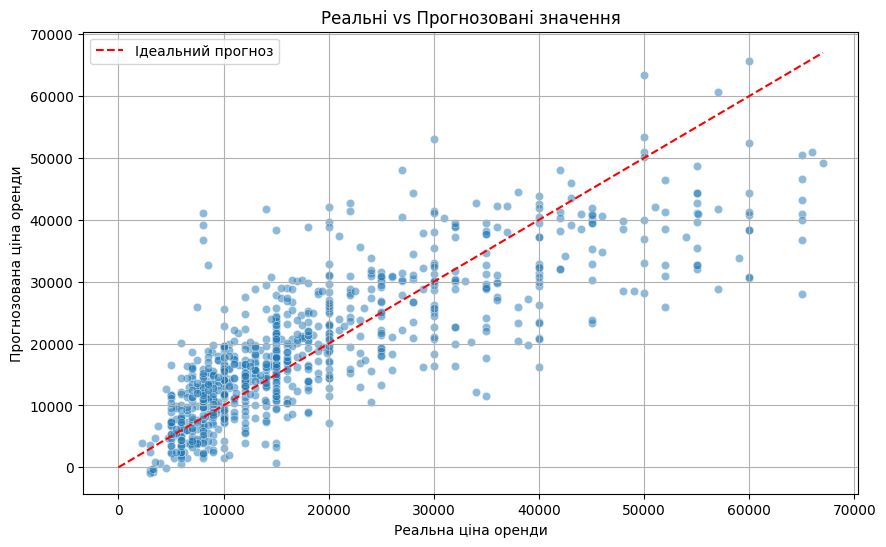

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)

# Лінія ідеального прогнозу
max_val = max(max(y_test), max(y_test_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Ідеальний прогноз')

plt.xlabel('Реальна ціна оренди')
plt.ylabel('Прогнозована ціна оренди')
plt.title('Реальні vs Прогнозовані значення')
plt.legend()
plt.grid(True)
plt.show()

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

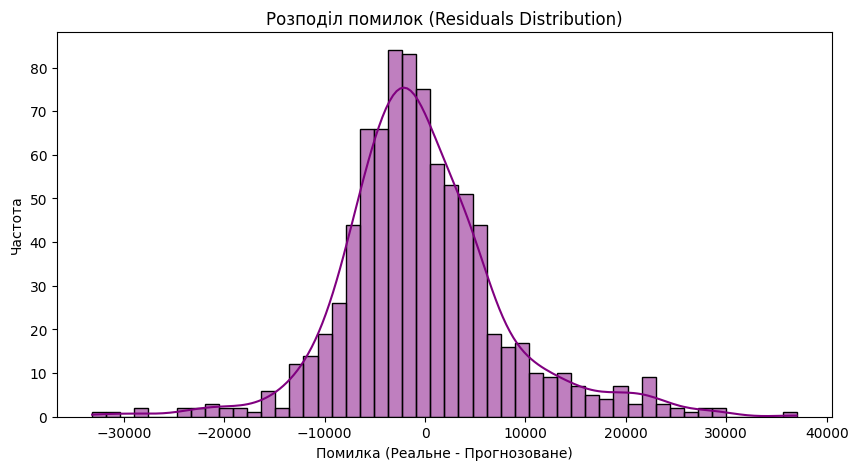

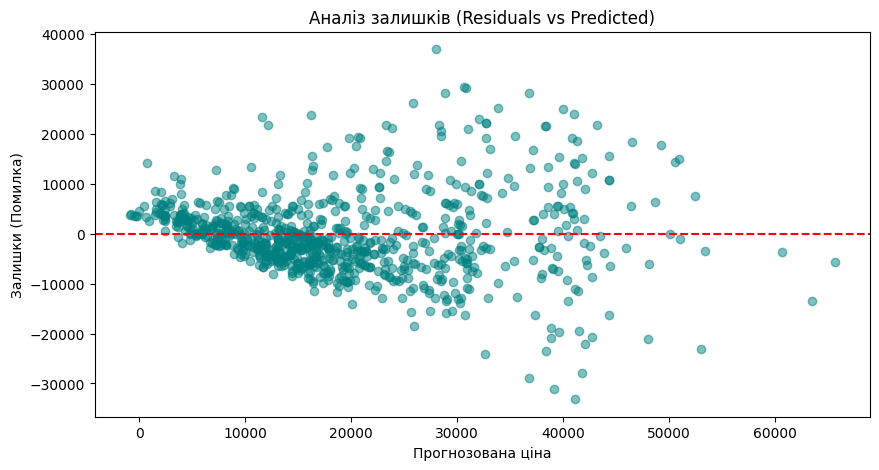

In [46]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=50, color='purple')
plt.title('Розподіл помилок (Residuals Distribution)')
plt.xlabel('Помилка (Реальне - Прогнозоване)')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_test_pred, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Аналіз залишків (Residuals vs Predicted)')
plt.xlabel('Прогнозована ціна')
plt.ylabel('Залишки (Помилка)')
plt.show()

Графік чітко демонструє явище гетероскедастичності:

На низьких значеннях ціни (до 20 000) помилки купчаться близько до нуля (модель точна).

З ростом прогнозованої ціни розкид залишків збільшується, утворюючи форму "факела" або "конуса".

Помилка росте з ростом прогнозованого значення. Модель стає менш впевненою, коли справа доходить до дорожчого житла.

In [48]:
error_analysis = X_test.copy()

error_analysis['Real_Rent'] = y_test
error_analysis['Pred_Rent'] = y_test_pred
error_analysis['Abs_Error'] = abs(residuals)

top_5_errors = error_analysis.sort_values(by='Abs_Error', ascending=False).head(5)
print("Топ-5 прогнозів з найбільшими помилками:")
print(top_5_errors[['Real_Rent', 'Pred_Rent', 'Abs_Error']])

Топ-5 прогнозів з найбільшими помилками:
      Real_Rent     Pred_Rent     Abs_Error
3520      65000  27989.441076  37010.558924
852        8000  41152.379540  33152.379540
549        8000  39146.809689  31146.809689
2658      60000  30610.421265  29389.578735
809       60000  30809.313939  29190.686061


In [49]:
X_test.loc[3520]

,3520
BHK,3
Size,1444
Bathroom,3
Bath_per_BHK,1.0
Area Type_Carpet Area,False
Area Type_Super Area,True
City_Chennai,True
City_Delhi,False
City_Hyderabad,False
City_Kolkata,False


Об'єкт розташований у Ченнаї, яка має від'ємну вагу (-1639.55) порівняно з базовим містом. Модель сприймає це місто як відносно недороге, що тягне прогноз ціни вниз.

Це велика квартира (3 кімнати, 1444 кв. фути). Хоча площа додає вартості, лінійна залежність $Size \times 9.02$ додає лише близько 13 000 до базової ціни.

Значення True для Super Area також мало негативний коефіцієнт у моделі (-3523.78). Це ще сильніше занизило очікування моделі щодо цього об'єкта.

Оскільки ми видалили Area Locality, модель не знає, що цей фактор може сильно впливати на формування ціни.

In [50]:
X_test.loc[852]

,852
BHK,2
Size,890
Bathroom,2
Bath_per_BHK,1.0
Area Type_Carpet Area,True
Area Type_Super Area,False
City_Chennai,False
City_Delhi,False
City_Hyderabad,False
City_Kolkata,False


Коефіцієнт City_Mumbai: True у моделі є найбільшим і додає понад 22 762 до ціни.

Для Мумбаї квартира площею 890 кв. футів із двома ванними кімнатами — це солідне житло середнього класу. Математично модель додає вагу за площу та кількість санвузлів, що ще більше піднімає прогноз.

Carpet Area має менший негативний вплив, ніж Super Area, що залишило прогноз високим.

Що сталося насправді?
Реальна ціна 8 000 для такої квартири в Мумбаї — це аномально низьке значення. Це може бути пояснено факторами, які модель не бачить:

Оскільки ми видалили Area Locality, модель не бачить, чи це трущоби чи центр міста.

Параметр Unfurnished: True підтверджує, що житло пусте, але не передає його фізичний стан.

Не можна виключати, що в самому датасеті припустилися помилки.

Як покращити якість моделі?

Логарифмування цілі: оскільки помилка зростає разом із ціною, перехід до логарифмічної шкали допоможе лінійній регресії краще обробляти дорогі об'єкти та зменшить гетероскедастичність.

Додавання ознаки Price per Square Foot, що домоможе достовірніше прогнозувати ціну, аналіз вартості квадратного метра в розрізі міст допоможе краще ідентифікувати райони.

Використання Target Encoding для Area Locality: видалення цієї колонки врятувало від перенавчання, але ми втратили важливу інформацію. Можна замінити назву району на середню ціну оренди в ньому.

Використати нелінійні моделі (Random Forest/XGBoost). Дерево рішень набагато краще впораються з такими аномаліями.